In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

TV = np.random.uniform(0, 300, n)
Radio = np.random.uniform(0, 50, n)
Newspaper = np.random.uniform(0, 100, n)

# True relationship (with noise)
Sales = (
    3
    + 0.045 * TV
    + 0.187 * Radio
    + 0.001 * Newspaper
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'TV': TV,
    'Radio': Radio,
    'Newspaper': Newspaper,
    'Sales': Sales
})

df.head()

,TV,Radio,Newspaper,Sales
0,112.362036,1.571459,64.203165,8.505501
1,285.214292,31.820521,8.413996,20.490294
2,219.598183,15.717799,16.162871,20.125198
3,179.597545,25.428535,89.855419,17.194719
4,46.805592,45.378324,60.642906,9.602356


In [3]:
import statsmodels.api as sm
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# add intercept
X = sm.add_constant(X)

In [5]:
model = sm.OLS(y,X).fit()
model.summary() # r2 is 0.871

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     216.2
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.47e-42
Time:                        08:28:11   Log-Likelihood:                -207.49
No. Observations:                 100   AIC:                             423.0
Df Residuals:                      96   BIC:                             433.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1999      0.656      3.356      0.001       0.899       3.501
TV             0.0478      0.002     21.538      0.000       0.043       0.052
Radio          0.1953      0.014     14.316      0.000       0.168       0.222
Newspaper      0.0076      0.007      1.113      0.268      -0.006       0.021
==============================================================================
Omnibus:                        5.375   Durbin-Watson:                   2.376
Prob(Omnibus):                  0.068   Jarque-Bera (JB):                4.964
Skew:                          -0.402   Prob(JB):                       0.0836
Kurtosis:                       3.738   Cond. No.                         580.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

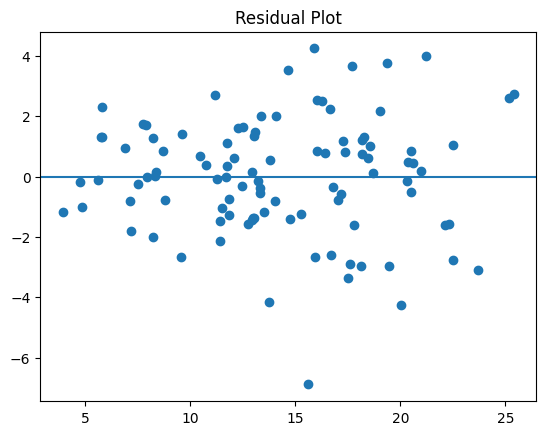

In [7]:
import matplotlib.pyplot as plt

y_pred = model.predict(X)
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()
#good it is a random scatter


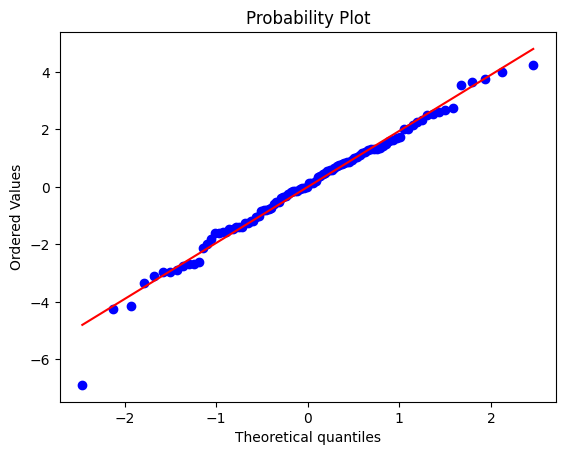

In [8]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()